In [32]:
import pandas as pd
import numpy as np
import scipy.io  
import torch
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
mat = scipy.io.loadmat('Xtrain.mat')




In [24]:
print(mat.keys())

Xtrain_mat = mat['Xtrain']
print(Xtrain_mat.dtype)
# Xtrain_mat_type = Xtrain_mat.dtype
# print(Xtrain_mat)


dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])
uint8


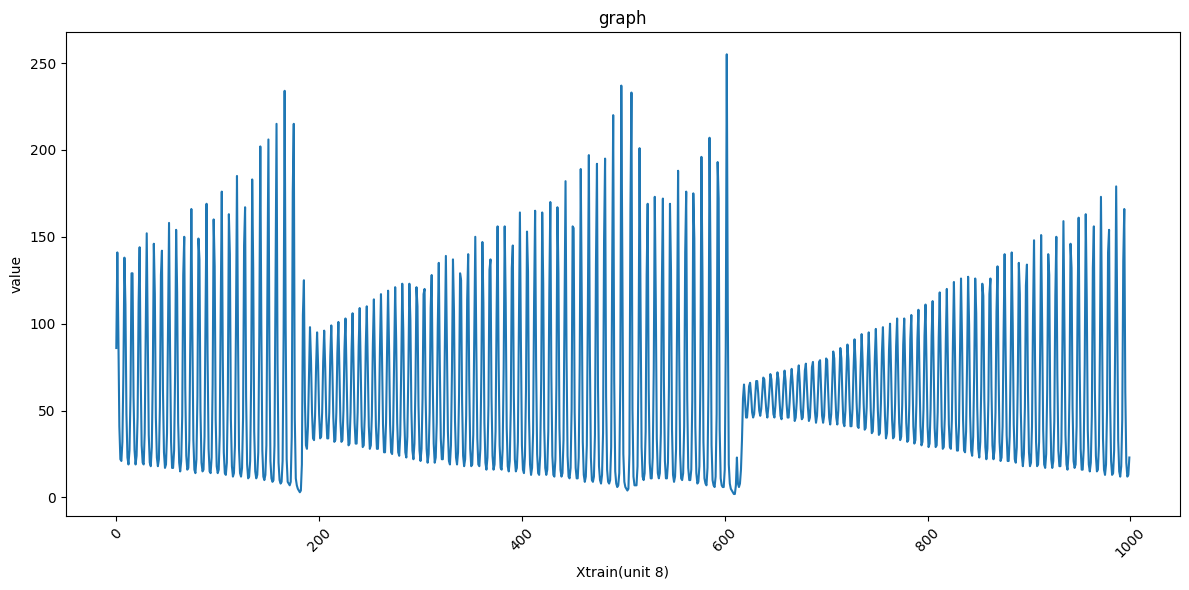

In [45]:
data = {}
for i in Xtrain_mat:
    if i[0] not in data:
        data[i[0]] = 1
    else:
        data[i[0]] +=1

plt.figure(figsize= (12,6))
plt.plot(Xtrain_mat)
plt.xlabel('Xtrain(unit 8)')
plt.xticks(rotation= 45)
plt.ylabel('value')
plt.title('graph')
plt.tight_layout()

plt.show()

In [33]:
Xtrain_arr = np.array(Xtrain_mat)
Xtrain_arr.shape

(1000, 1)

In [ ]:
# scale dataset

num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
])

Xtrain_arr_scale = num_pipeline.fit_transform(Xtrain_arr).flatten() # normalize input and flatten to 1D


In [6]:
values, counts = np.unique(Xtrain_mat[:, 0], return_counts = True)
print('values', values)
print('---')
print('counts', counts)
total_nr = sum(counts)
print('total_nr:', total_nr)

values [  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 144 145 146
 147 148 149 150 151 152 153 154 155 156 158 159 160 161 163 164 165 166
 167 169 170 172 173 175 176 179 182 183 185 188 189 192 193 195 196 197
 201 202 206 207 215 220 233 234 237 255]
---
counts [ 2  2  4  4  6 10 10 10 11 15 15 13 16 10 19 16 17 19 15 15 14 14 12  9
 11 13 18 10 17  7 14 11 10  8  9  8  7  6  6 19  6 13  5  9 20 14  6 13
 10  8 10  7  7  5  6  4  9  7  4  5  5  4  7  6  6  8  8  1  1 

In [42]:
# one-step ahead structure

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data)- window):
        X.append(data[i: i + window])
        y.append(data[i + window])

    return np.array(X), np.array(y)

X, y = create_dataset(Xtrain_arr_scale, 1)

print(X.shape)
print(y.shape)

(999, 1)
(999,)


In [ ]:
# split data based on sliding window split (train set: from past data, test set: from future data)

tscv = TimeSeriesSplit(n_splits = 5)
fold_result = []


In [44]:
# neural network
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F




In [ ]:

for idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]
    

    

    


c:\Users\panlw\Desktop\Utrecht master\DL_assignment\dl_assignment1\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[ 25.87093102  25.20173163  24.53161338  25.87093102  42.61198142
 125.49874805 148.42487499  49.07832492  27.1934933   24.53161338
  23.11820435  22.31838563  21.51110888  22.31838563  32.45007802
  83.76144003  95.51842821  54.3689696   39.63472472  38.32975921
  46.13907788  63.77456014  79.64649417  68.47735541  50.84187314
  42.02413201  41.43628261  49.66617433  66.12595777  77.88294595
  66.71380718  50.25402374  42.02413201  42.61198142  50.84187314
  67.889506    78.47079535  66.12595777  49.66617433  42.02413201
  42.02413201  50.84187314  69.65305422  80.23434358  66.71380718
  49.07832492  40.8484332   41.43628261  50.84187314  70.82875304
  81.4100424   65.53810836  47.9026261   40.8484332   41.43628261
  51.42972255  72.00445186  82.58574122  64.95025895  47.31477669
  39.63472472  40.26058379  50.84187314  72.00445186  84.34928944
  65.53810836  47.31477669  40.26058379  40.26058379  50.84187314
  73.18015068  86.11283767  66.71380718  46.13907788  38.98224196
  39.63472

c:\Users\panlw\Desktop\Utrecht master\DL_assignment\dl_assignment1\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[ 38.36750967  34.82137312  41.02711208  61.45142946  95.53025061
  93.5828894   59.50406825  39.2540438   33.93483899  37.48097553
  55.60934583  88.22764608 100.88549394  65.83299218  42.80018035
  33.93483899  34.82137312  49.89245343  78.00399973 105.75389696
  75.56979822  48.11938516  34.82137312  33.93483899  42.80018035
  67.78035339 104.29337605  87.25396547  53.66198463  35.70790726
  32.16177072  38.36750967  58.53038765  96.50393122  99.42497303
  60.96458916  39.2540438   32.16177072  34.82137312  51.22778312
  83.35924306 108.67493877  71.67507581  44.57324862  33.04830485
  32.16177072  42.80018035  69.2408743  108.67493877  87.25396547
  52.20146372  33.93483899  31.27523658  36.5944414   57.55670704
  96.99077152 103.31969545  61.45142946  37.48097553  31.27523658
  33.04830485  46.34631689  79.46452064 112.56966119  76.05663853
  44.57324862  32.16177072  30.38870245  39.2540438   62.91195037
 107.21441786  96.01709091  55.12250553  34.82137312  29.50082111
  33.04830

c:\Users\panlw\Desktop\Utrecht master\DL_assignment\dl_assignment1\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[ 22.1420219   18.50173351  17.26569299  16.01739929  17.26569299
  41.10443333 112.21504528 141.93872841  62.38416473  25.74248214
  19.71969204  19.71969204  19.71969204  32.88848061  75.06044137
 127.95111282  87.736718    45.79926346  25.74248214  23.345697
  28.13926728  55.51727613  96.04186475 113.96349723  67.62952058
  35.23589567  24.54408957  24.54408957  38.75701827  72.43776344
 115.71194918  89.92228293  51.66780112  28.13926728  24.54408957
  28.13926728  54.96994657  93.41918683 115.27483619  69.37797253
  36.4096032   24.54408957  24.54408957  35.23589567  68.06663357
 113.96349723  97.35320372  56.04777469  26.94087471  22.1420219
  25.74248214  44.62555593  83.80270111 122.26864399  78.55734526
  41.10443333  24.54408957  23.345697    28.13926728  57.10877182
 101.72433359 117.02328814  65.00684266  31.71477308  23.345697
  23.345697    30.53605241  64.56972967 116.58617515 105.22123749
  57.10877182  28.13926728  20.93099704  22.1420219   32.88848061
  69.37797253 1